In [1]:
import numpy as np
import matplotlib.pyplot as plt
from hamsim.hamiltonian import ising
from hamsim.operators import kron_at
from hamsim.evolution import exact_evolve_series

In [2]:
# Ising 2-qubit transverse-field Hamiltonian
H = ising(J=np.pi, h=2*np.pi)
psi0 = np.array([0, 1, 0, 0], dtype=complex)  # |01>
times = np.linspace(0, 1, 200)
states = exact_evolve_series(H, psi0, times)

In [3]:
# observables: state probabilities and populations
n = 2  # number of qubits
Z = np.array([[1, 0], [0, -1]])
I = np.eye(4)
Zn = [kron_at(Z, i, n) for i in range(n)]
N = (I - Zn[0]@Zn[1]) / 2  # occcupation number operator
populations = [ states[t, :].conj().T @ N @ states[t, :] for t, _ in enumerate(times) ] 
probabilities = np.abs(states)**2   # shape (200, 4), elementwise |amplitude|^2

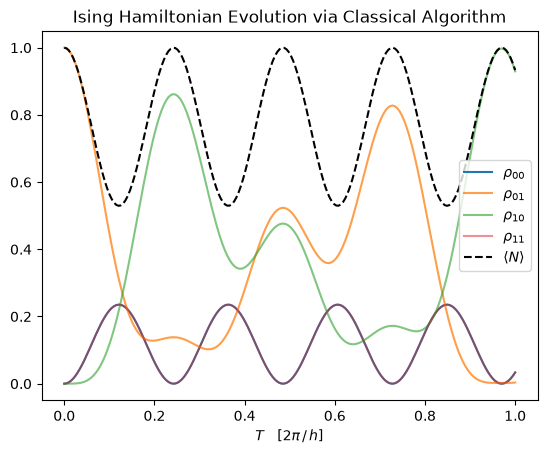

In [4]:
fig1, ax = plt.subplots(figsize=(6.4, 4.8))

slabels = [
    r"$\rho_{00}$",
    r"$\rho_{01}$",
    r"$\rho_{10}$",
    r"$\rho_{11}$",
]
for i in range(psi0.shape[0]):
    ax.plot(times, probabilities[:, i], label=slabels[i], alpha=3/(i+3))
    ax.set_xlabel(r"$T \quad [2\pi\,/\,h]$")

ax.plot(times, np.array(populations).real, '--k', label= r"$\langle N \rangle$")
ax.set_title(f"Ising Hamiltonian Evolution via Classical Algorithm")

plt.legend()